<a href="https://colab.research.google.com/github/Chaidir110/PCVK_Ganjil_2025/blob/main/week5_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# D-1 PERCOBAAN HISTOGRAM

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import cv2 as cv
from google.colab.patches import cv_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import os
import glob

<BarContainer object of 256 artists>

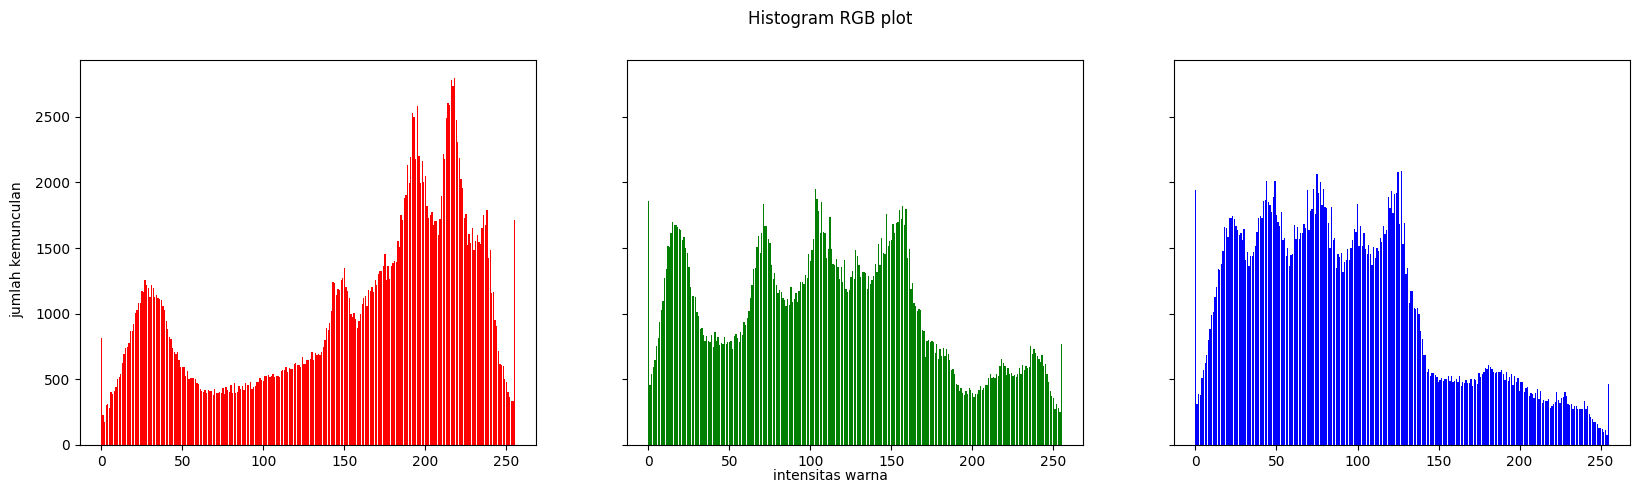

In [ ]:
#
img = cv.imread('/content/drive/MyDrive/RPL/PCVK/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(height):
  for x in range(width):
    red[img[y][x] [0]] += 1
    green[img[y][x] [1]] += 1
    blue[img[y][x] [2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'jumlah kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'intensitas warna', ha='center')
axs[0].bar(names, red, color='r')
axs[1].bar(names, green, color='g')
axs[2].bar(names, blue, color='b')

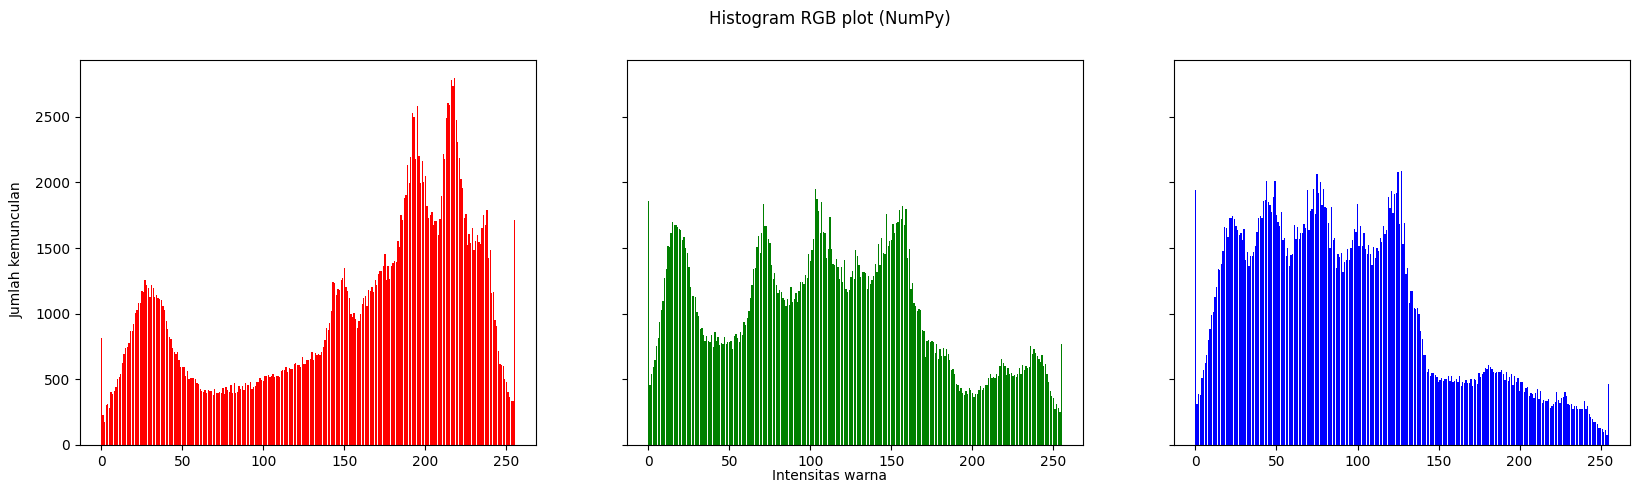

In [ ]:
# Baca gambar
img = cv.imread('/content/drive/MyDrive/RPL/PCVK/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Pisahkan channel R, G, B
R = img[:,:,0].flatten()
G = img[:,:,1].flatten()
B = img[:,:,2].flatten()

# Hitung histogram pakai numpy
hist_r, bins_r = np.histogram(R, bins=256, range=(0,256))
hist_g, bins_g = np.histogram(G, bins=256, range=(0,256))
hist_b, bins_b = np.histogram(B, bins=256, range=(0,256))

# Plot hasil
names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot (NumPy)')
fig.text(0.09, 0.5, 'Jumlah kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas warna', ha='center')
axs[0].bar(names, hist_r, color='r')
axs[1].bar(names, hist_g, color='g')
axs[2].bar(names, hist_b, color='b')
plt.show()

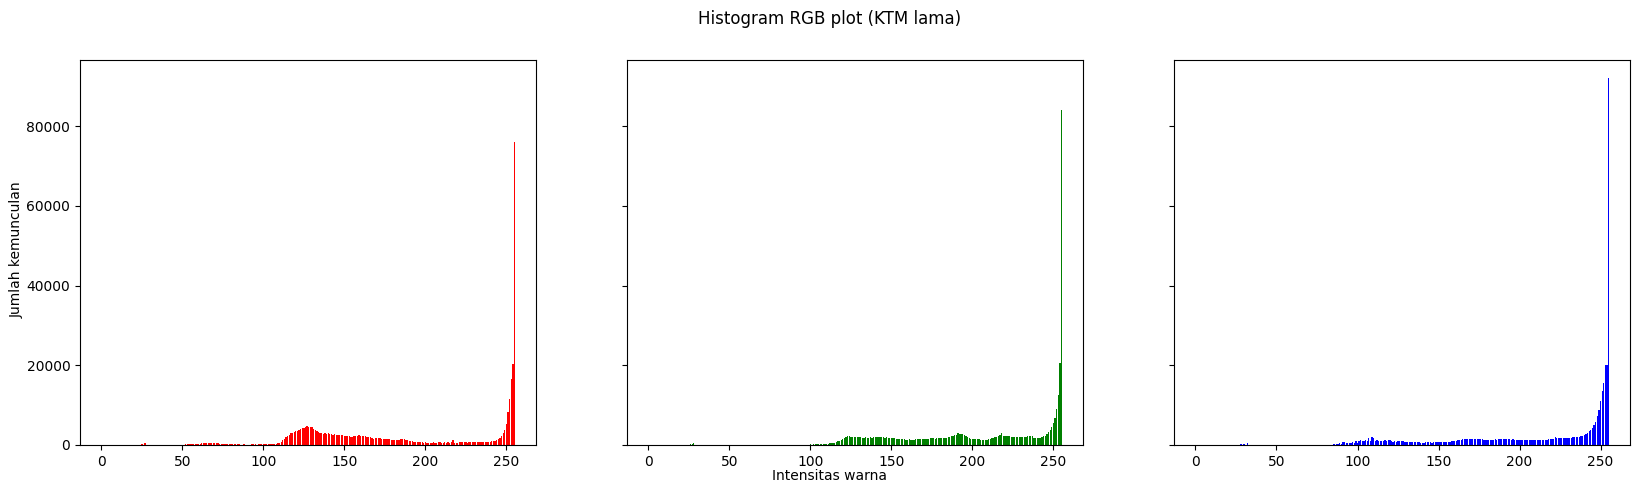

In [ ]:
# Baca gambar
img = cv.imread('/content/drive/MyDrive/RPL/PCVK/KTM lama.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Ambil ukuran gambar
height, width, depth = np.shape(img)

# Array kosong untuk histogram
red = [0]*256
green = [0]*256
blue = [0]*256

# Hitung distribusi intensitas tiap kanal
for y in range(height):
    for x in range(width):
        red[img[y][x][0]] += 1
        green[img[y][x][1]] += 1
        blue[img[y][x][2]] += 1

names = np.arange(256)

# Plot histogram
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot (KTM lama)')
fig.text(0.09, 0.5, 'Jumlah kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas warna', ha='center')
axs[0].bar(names, red, color='r')
axs[1].bar(names, green, color='g')
axs[2].bar(names, blue, color='b')
plt.show()


# D-2 PERCOBAAN HISTOGRAM EQUALIZATION

<BarContainer object of 256 artists>

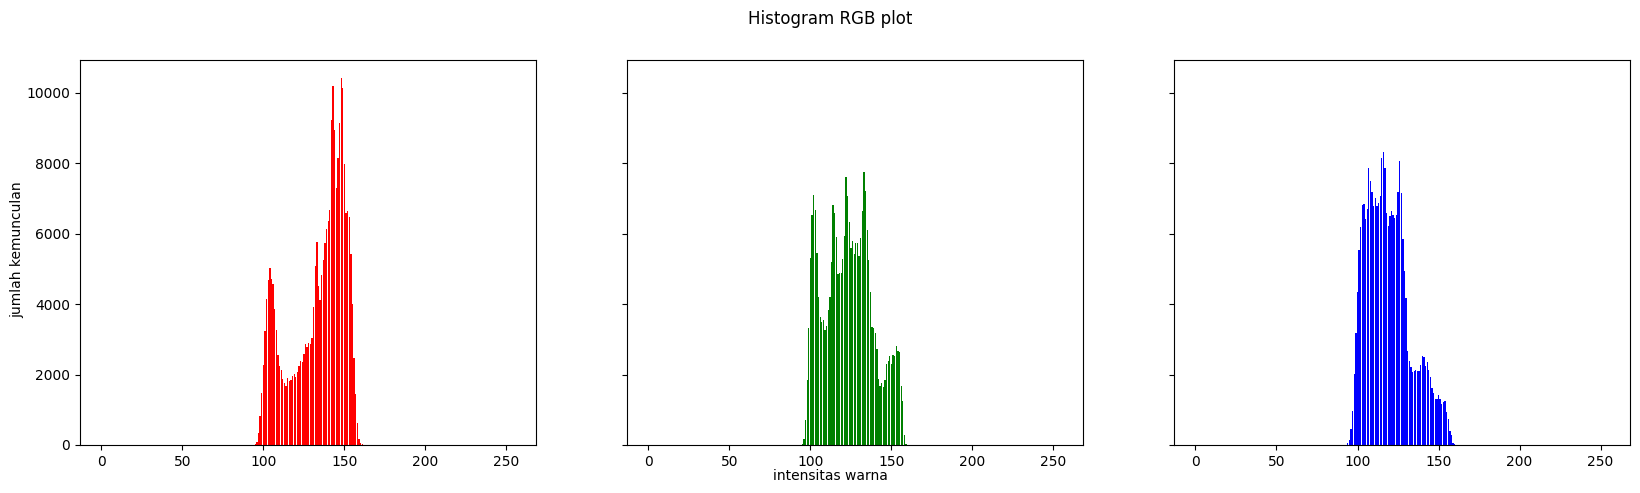

In [ ]:
#
img = cv.imread('/content/drive/MyDrive/RPL/PCVK/lena_lc.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(height):
  for x in range(width):
    red[img[y][x] [0]] += 1
    green[img[y][x] [1]] += 1
    blue[img[y][x] [2]] += 1



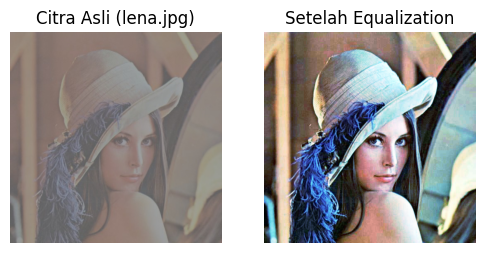

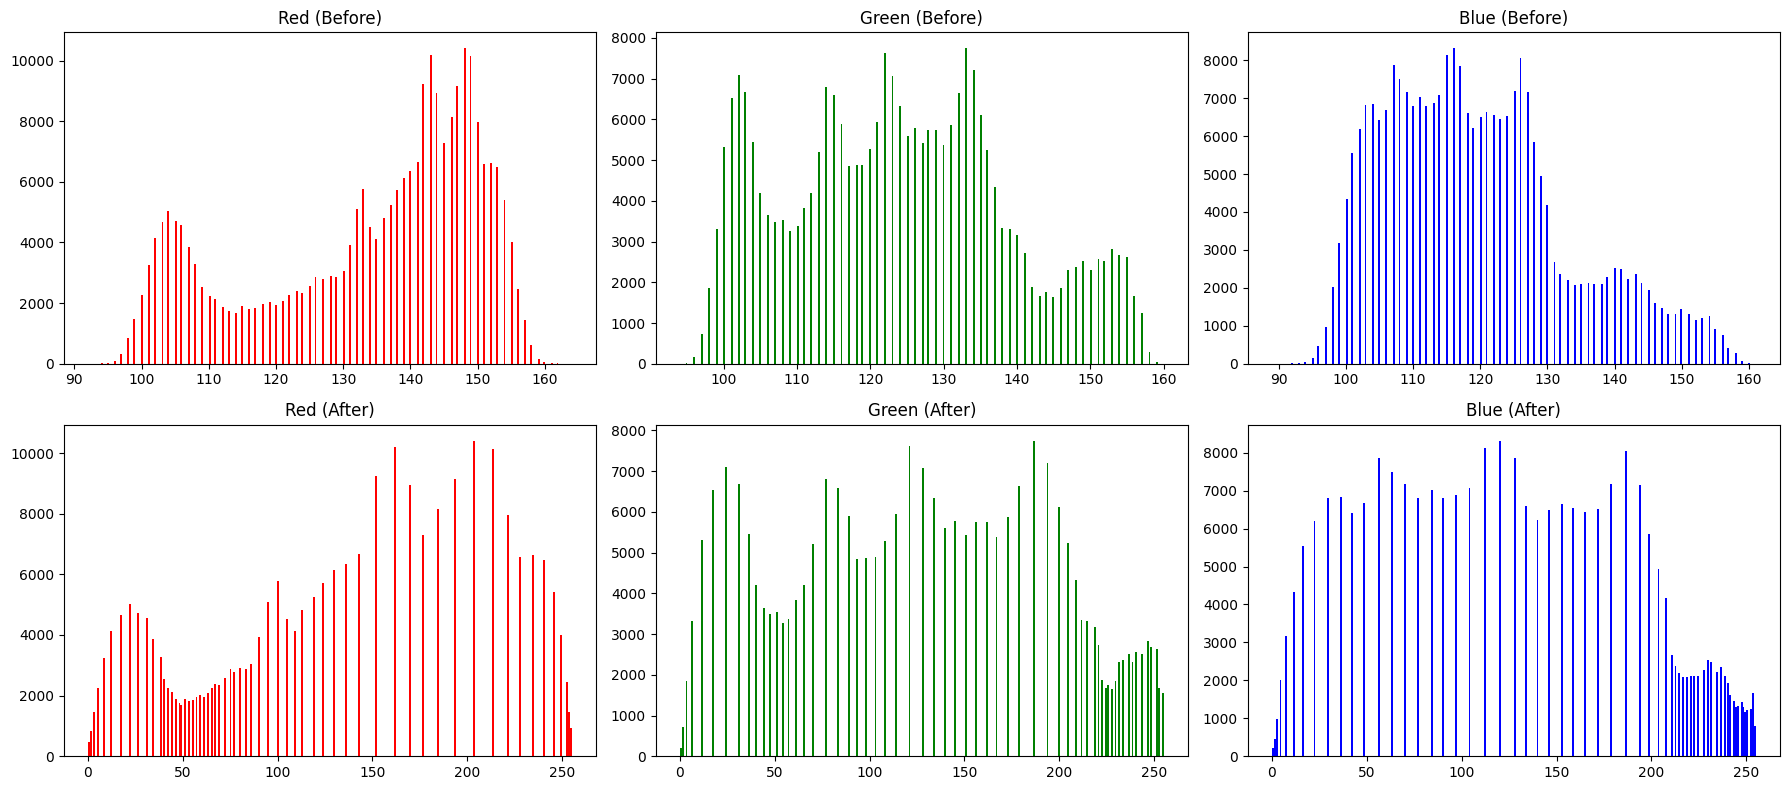

In [27]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Load image
img = cv.imread('/content/drive/MyDrive/RPL/PCVK/lena_lc.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Ambil dimensi
height, width, depth = img.shape
total_pixels = height * width

# Fungsi manual histogram equalization
def hist_equalization(channel):
    # Hitung histogram
    hist = np.zeros(256, dtype=int)
    for y in range(height):
        for x in range(width):
            hist[channel[y, x]] += 1

    # Hitung CDF(Cumulative Distribution Function)
    cdf = np.cumsum(hist)
    cdf_min = np.min(cdf[np.nonzero(cdf)])
    equalized_map = np.round((cdf - cdf_min) / (total_pixels - cdf_min) * 255).astype('uint8')

    # Mapping pixel lama ke pixel baru
    eq_channel = equalized_map[channel]
    return eq_channel

# Pisahkan channel RGB
r, g, b = cv.split(img)

# Equalization tiap channel
r_eq = hist_equalization(r)
g_eq = hist_equalization(g)
b_eq = hist_equalization(b)

# Gabungkan kembali jadi RGB
img_eq = cv.merge([r_eq, g_eq, b_eq])

# Tampilkan citra asli vs equalization
plt.figure(figsize=(6,3))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Citra Asli (lena.jpg)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_eq)
plt.title(f"Setelah Equalization")
plt.axis("off")

plt.show()

# Tampilkan histogram RGB sebelum & sesudah
fig, axs = plt.subplots(2, 3, figsize=(18,8))

# Histogram sebelum
axs[0,0].hist(r.ravel(), bins=256, color='red')
axs[0,0].set_title("Red (Before)")

axs[0,1].hist(g.ravel(), bins=256, color='green')
axs[0,1].set_title("Green (Before)")

axs[0,2].hist(b.ravel(), bins=256, color='blue')
axs[0,2].set_title("Blue (Before)")

# Histogram sesudah
axs[1,0].hist(r_eq.ravel(), bins=256, color='red')
axs[1,0].set_title("Red (After)")

axs[1,1].hist(g_eq.ravel(), bins=256, color='green')
axs[1,1].set_title("Green (After)")

axs[1,2].hist(b_eq.ravel(), bins=256, color='blue')
axs[1,2].set_title("Blue (After)")

plt.tight_layout()
plt.show()

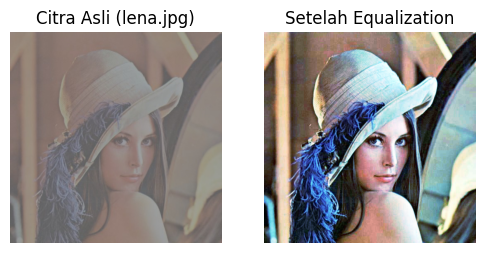

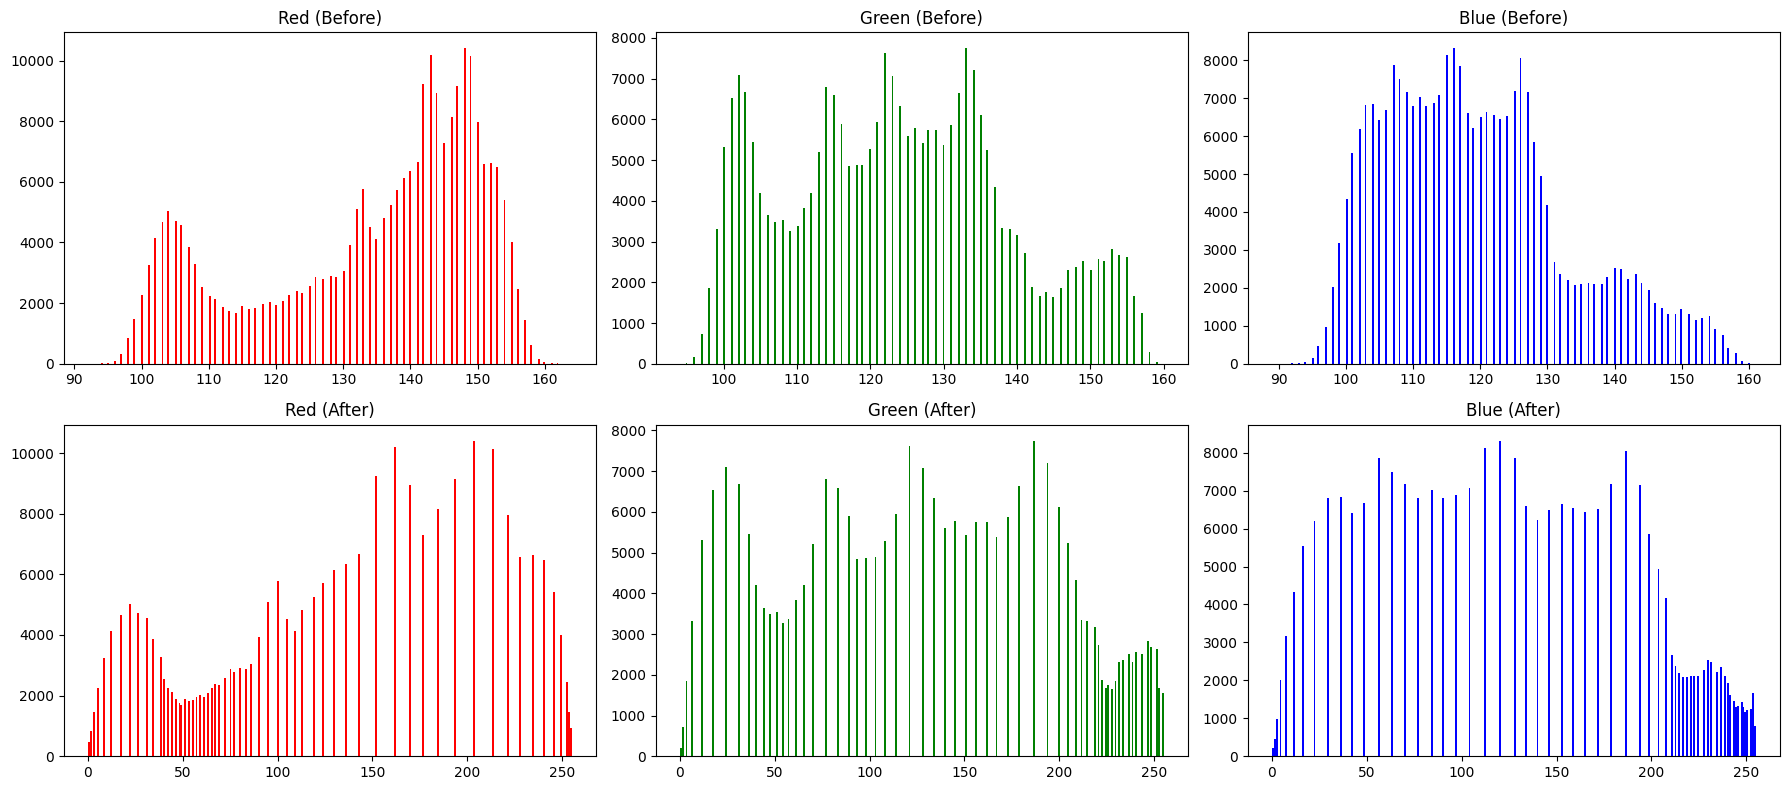

In [29]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Load image
img = cv.imread('/content/drive/MyDrive/RPL/PCVK/lena_lc.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Pisahkan channel RGB
r, g, b = cv.split(img)

# Equalization dengan library OpenCV
r_eq = cv.equalizeHist(r)
g_eq = cv.equalizeHist(g)
b_eq = cv.equalizeHist(b)

# Gabungkan kembali jadi gambar RGB
img_eq = cv.merge([r_eq, g_eq, b_eq])

# Tampilkan citra asli vs equalization
plt.figure(figsize=(6,3))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Citra Asli (lena.jpg)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_eq)
plt.title(f"Setelah Equalization")
plt.axis("off")

plt.show()

# Tampilkan histogram RGB sebelum & sesudah
fig, axs = plt.subplots(2, 3, figsize=(18,8))

# Histogram sebelum
axs[0,0].hist(r.ravel(), bins=256, color='red')
axs[0,0].set_title("Red (Before)")

axs[0,1].hist(g.ravel(), bins=256, color='green')
axs[0,1].set_title("Green (Before)")

axs[0,2].hist(b.ravel(), bins=256, color='blue')
axs[0,2].set_title("Blue (Before)")

# Histogram sesudah
axs[1,0].hist(r_eq.ravel(), bins=256, color='red')
axs[1,0].set_title("Red (After)")

axs[1,1].hist(g_eq.ravel(), bins=256, color='green')
axs[1,1].set_title("Green (After)")

axs[1,2].hist(b_eq.ravel(), bins=256, color='blue')
axs[1,2].set_title("Blue (After)")

plt.tight_layout()
plt.show()

PSNR antara lena.jpg dan hasil equalization: 17.948401139690418 dB


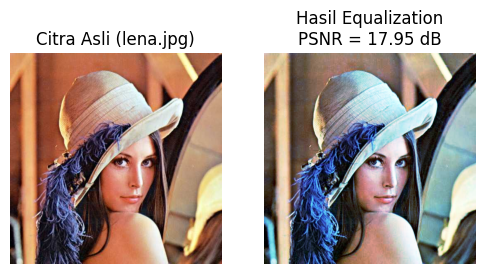

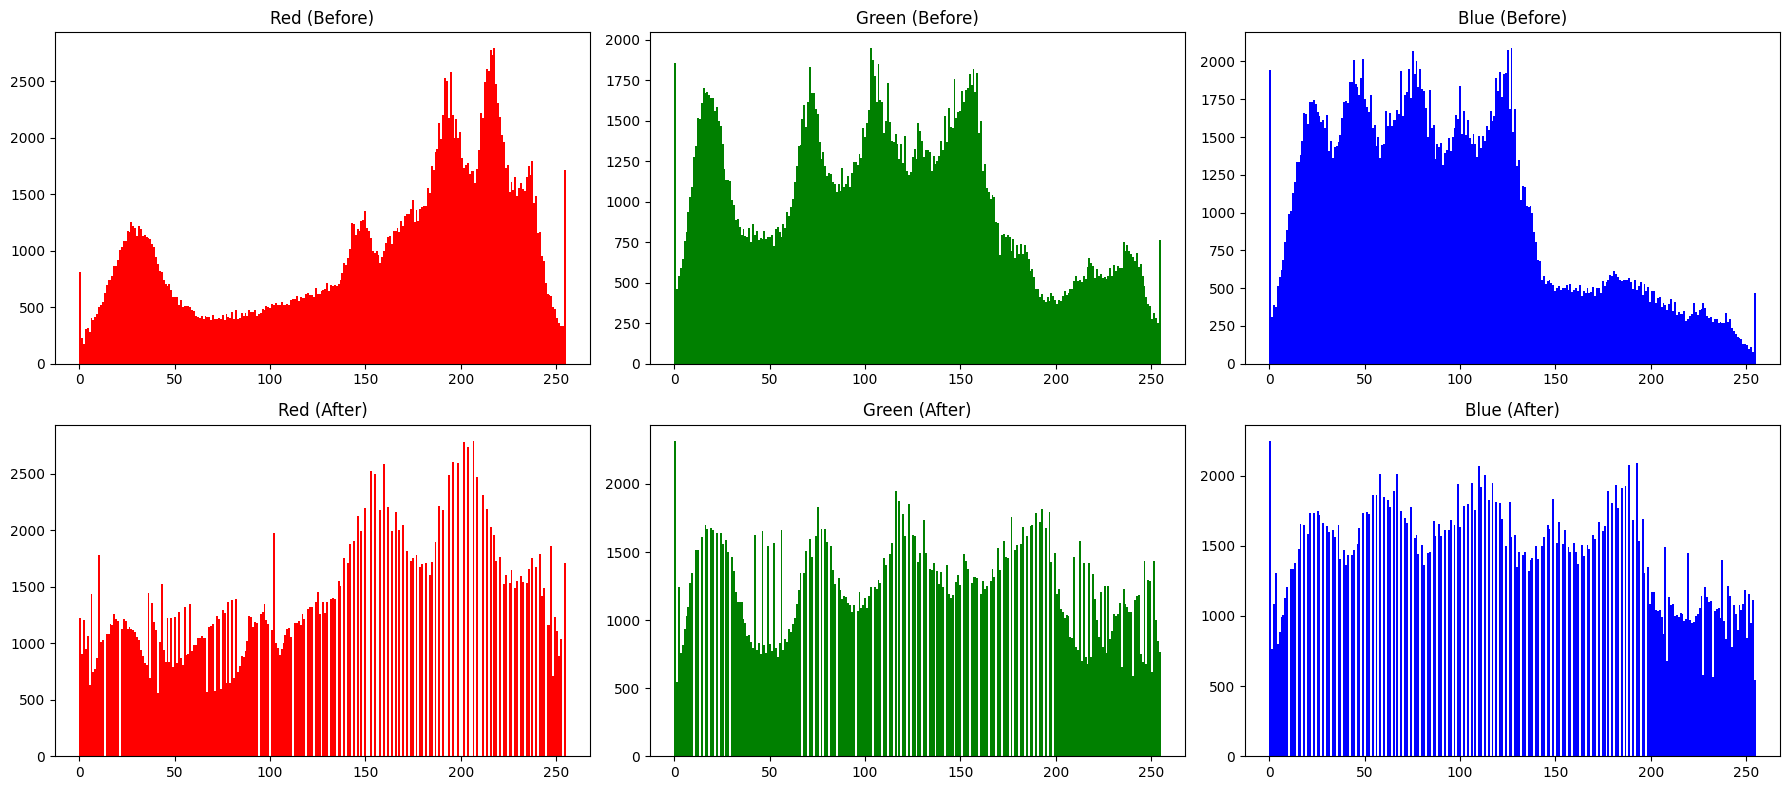

In [34]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import math

# Load citra asli lena.jpg
img = cv.imread('/content/drive/MyDrive/RPL/PCVK/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Pisahkan channel RGB
r, g, b = cv.split(img)

# Lakukan histogram equalization dengan OpenCV
r_eq = cv.equalizeHist(r)
g_eq = cv.equalizeHist(g)
b_eq = cv.equalizeHist(b)

# Gabungkan jadi hasil equalization
img_eq = cv.merge([r_eq, g_eq, b_eq])

# Fungsi PSNR
def calculate_psnr(original, processed):
    mse = np.mean((original.astype(np.float32) - processed.astype(np.float32)) ** 2)
    if mse == 0:
        return float('inf')
    max_pixel = 255.0
    psnr = 10 * math.log10((max_pixel ** 2) / mse)
    return psnr

# Hitung PSNR
psnr_value = calculate_psnr(img, img_eq)
print("PSNR antara lena.jpg dan hasil equalization:", psnr_value, "dB")

# Tampilkan citra asli vs equalization
plt.figure(figsize=(6,3))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Citra Asli (lena.jpg)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_eq)
plt.title(f"Hasil Equalization\nPSNR = {psnr_value:.2f} dB")
plt.axis("off")

plt.show()

# Tampilkan histogram RGB sebelum & sesudah
fig, axs = plt.subplots(2, 3, figsize=(18,8))

# Histogram sebelum
axs[0,0].hist(r.ravel(), bins=256, color='red')
axs[0,0].set_title("Red (Before)")

axs[0,1].hist(g.ravel(), bins=256, color='green')
axs[0,1].set_title("Green (Before)")

axs[0,2].hist(b.ravel(), bins=256, color='blue')
axs[0,2].set_title("Blue (Before)")

# Histogram sesudah
axs[1,0].hist(r_eq.ravel(), bins=256, color='red')
axs[1,0].set_title("Red (After)")

axs[1,1].hist(g_eq.ravel(), bins=256, color='green')
axs[1,1].set_title("Green (After)")

axs[1,2].hist(b_eq.ravel(), bins=256, color='blue')
axs[1,2].set_title("Blue (After)")

plt.tight_layout()
plt.show()

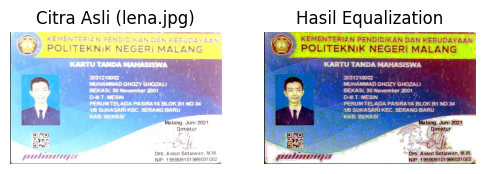

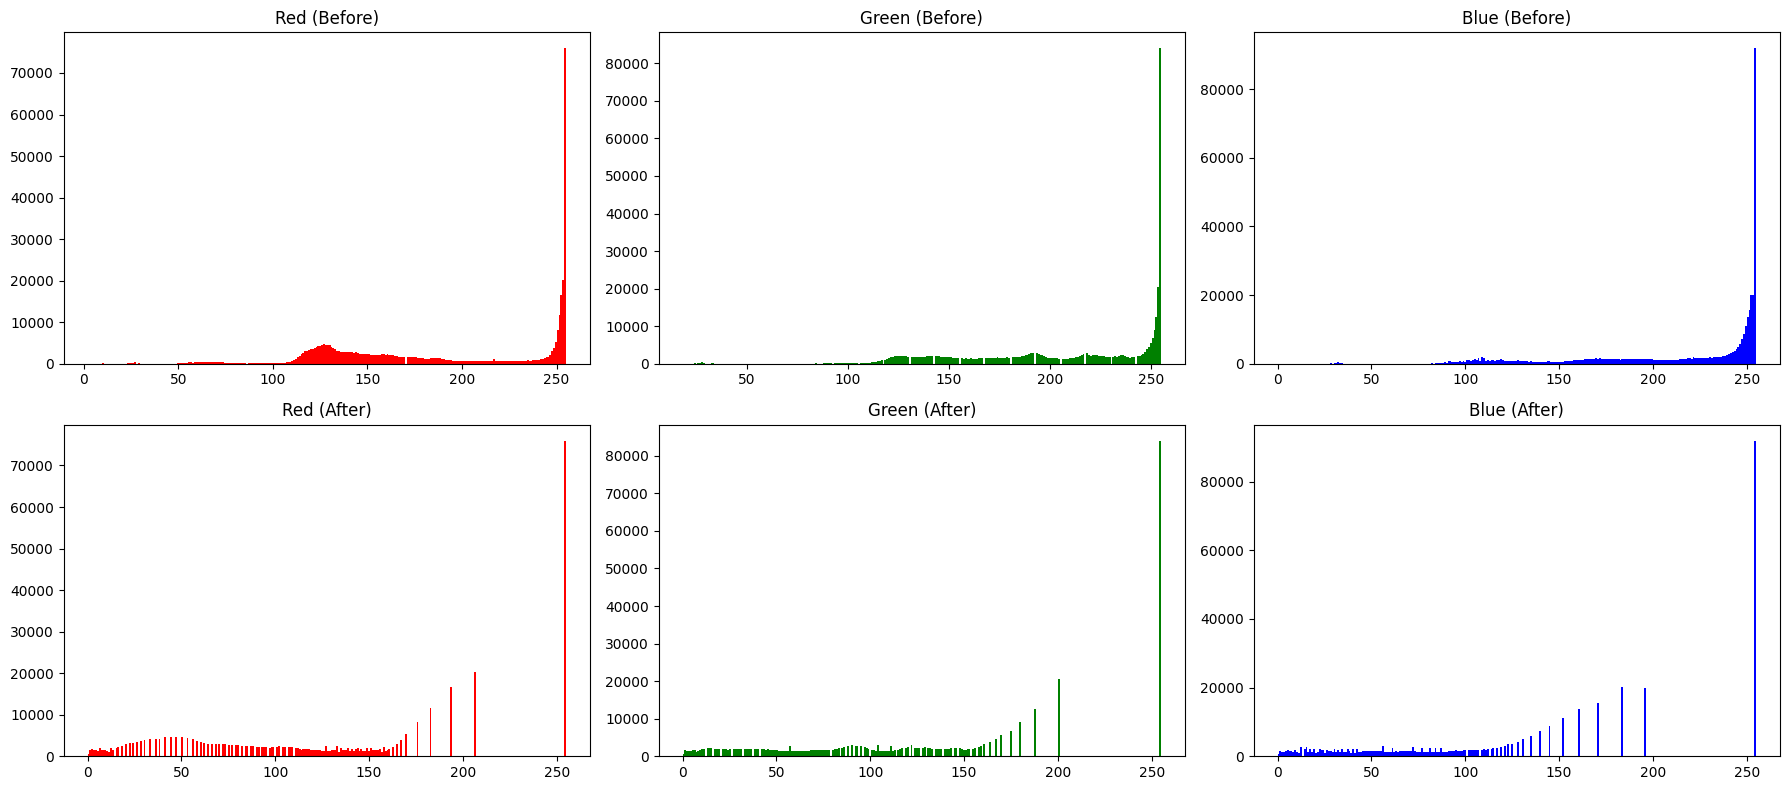

In [33]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Load image
img = cv.imread('/content/drive/MyDrive/RPL/PCVK/KTM lama.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Pisahkan channel RGB
r, g, b = cv.split(img)

# Equalization dengan library OpenCV
r_eq = cv.equalizeHist(r)
g_eq = cv.equalizeHist(g)
b_eq = cv.equalizeHist(b)

# Gabungkan kembali jadi gambar RGB
img_eq = cv.merge([r_eq, g_eq, b_eq])

# Tampilkan citra asli vs equalization
plt.figure(figsize=(6,3))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Citra Asli (lena.jpg)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_eq)
plt.title(f"Hasil Equalization")
plt.axis("off")

plt.show()

# Tampilkan histogram RGB sebelum & sesudah
fig, axs = plt.subplots(2, 3, figsize=(18,8))

# Histogram sebelum
axs[0,0].hist(r.ravel(), bins=256, color='red')
axs[0,0].set_title("Red (Before)")

axs[0,1].hist(g.ravel(), bins=256, color='green')
axs[0,1].set_title("Green (Before)")

axs[0,2].hist(b.ravel(), bins=256, color='blue')
axs[0,2].set_title("Blue (Before)")

# Histogram sesudah
axs[1,0].hist(r_eq.ravel(), bins=256, color='red')
axs[1,0].set_title("Red (After)")

axs[1,1].hist(g_eq.ravel(), bins=256, color='green')
axs[1,1].set_title("Green (After)")

axs[1,2].hist(b_eq.ravel(), bins=256, color='blue')
axs[1,2].set_title("Blue (After)")

plt.tight_layout()
plt.show()